In [1]:
import numpy as np
import pandas as pd

!pip install seaborn
import seaborn as sns



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


# Task 0
Read the dataset from csv file & perform data cleaning - remove all rows, which contains `?` in some columns.
Also check for data correctness (salary & salary $K).

In [8]:
df = pd.read_csv('../data/adult.csv')

#replace ? with NaN
df = df.replace('?', np.nan)
# remove rows with NaN
df_cleaned = df.dropna()

#check that there is no salary less than 0
if (df_cleaned['salary K$'] < 0).any():
    raise ValueError("Error: There are salaries less than 0 in the data.")
else:
    print("Salary data is correct. No salary is less than 0.")




,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$


# Task 1
Print the count of men and women in the dataset.

In [3]:
gender_count = df['sex'].value_counts()
print(gender_count)

Male      21790
Female    10771
Name: sex, dtype: int64


# Task 2
Find the average age of men in dataset

In [4]:
men = df[df['sex']=='Male']
average_age = men['age'].mean()
average_age

39.43354749885268

# Task 3
Get the percentage of people from Poland (native-country)

In [5]:
polish = df[df['native-country']=='Poland'].shape[0]
total = df.shape[0]
polish_percentage = polish * 100 / total
polish_percentage



0.18426952489174164

# Task 4
Get the mean and standard deviation of the age for people who earn > 50K per year. After this, get it for those who earn <= 50K.

In [7]:
earn_more_than_50 = df[df['salary'] == '>50K']
mean_age_more_50 = earn_more_than_50['age'].mean()
std_age_more_50 = earn_more_than_50['age'].std()
earn_less_than_50 = df[df['salary'] == '<=50K']
mean_age_less_50 = earn_less_than_50['age'].mean()
std_age_less_50 = earn_less_than_50['age'].std()
print(mean_age_less_50)
print(std_age_less_50)



,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
0,0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K,39
1,1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K,35
2,2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K,27
3,3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K,43
4,4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K,25


# Task 5
Check, if there are some people without higher education (education: Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters, Doctorate), but with > 50K salary

In [12]:
education = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
without_education = df[~df['education'].isin(education)]
without_education_and_earn = without_education[without_education['salary'] == '>50K']
without_education_and_earn

,Unnamed: 0,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,salary,salary K$
7,7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,45,United-States,>50K,307
10,10,37,Private,Some-college,Married-civ-spouse,Exec-managerial,Husband,Black,Male,80,United-States,>50K,116
27,27,54,NaN,Some-college,Married-civ-spouse,NaN,Husband,Asian-Pac-Islander,Male,60,South,>50K,275
38,38,31,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,38,NaN,>50K,166
55,55,43,Private,Some-college,Married-civ-spouse,Tech-support,Husband,White,Male,40,United-States,>50K,341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32510,32510,39,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,45,NaN,>50K,212
32518,32518,57,Local-gov,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,40,United-States,>50K,116
32519,32519,46,Private,Some-college,Married-civ-spouse,Exec-managerial,Husband,White,Male,48,United-States,>50K,239
32557,32557,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K,173


# Task 6
Get the statistics of age for each type of education. Use `groupby` and `describe` for this.

In [25]:
df.groupby(['education'])['age'].describe()

,count,mean,std,min,25%,50%,75%,max
education,,,,,,,,
10th,933.0,37.429796,16.720713,17.0,22.00,34.0,52.0,90.0
11th,1175.0,32.355745,15.545485,17.0,18.00,28.0,43.0,90.0
12th,433.0,32.000000,14.334625,17.0,19.00,28.0,41.0,79.0
1st-4th,168.0,46.142857,15.615625,19.0,33.00,46.0,57.0,90.0
5th-6th,333.0,42.885886,15.557285,17.0,29.00,42.0,54.0,84.0
7th-8th,646.0,48.445820,16.092350,17.0,34.25,50.0,61.0,90.0
9th,514.0,41.060311,15.946862,17.0,28.00,39.0,54.0,90.0
Assoc-acdm,1067.0,37.381443,11.095177,19.0,29.00,36.0,44.0,90.0
Assoc-voc,1382.0,38.553546,11.631300,19.0,30.00,37.0,46.0,84.0


# Task 7
Compare the married and non-married men salaries. Who earns more? (>50K or <=50K)
Married men are those, whom `marital-status` starts with "Married". Others are not.

In [31]:
men = df[df['sex'] == 'Male'].copy()

married = men[men['marital-status'].str.startswith('Married')]
not_married = men[~men['marital-status'].str.startswith('Married')]

married_total = married.shape[0]
not_married_total = not_married.shape[0]

married_earn = married[married['salary'] == '>50K'].shape[0]
not_married_earn = not_married[not_married['salary'] == '>50K'].shape[0]

married_rich_percentage = married_earn / married_total * 100
not_married_rich_percentage = not_married_earn / not_married_total * 100

if married_rich_percentage > not_married_rich_percentage:
    print('Married earn more')
else: 
    print('Not-married earn more')





Married earn more


# Task 8
Get the max hours per week some person works. How many people works the same amount of hours per week?

In [41]:
value = df['hours-per-week'].max()
df[df['hours-per-week'] == value].shape[0]

85

# Task 9
Analyze the correlation between data in dataset. Understand connected fields in it and print highlight thier connection.

<Axes: >

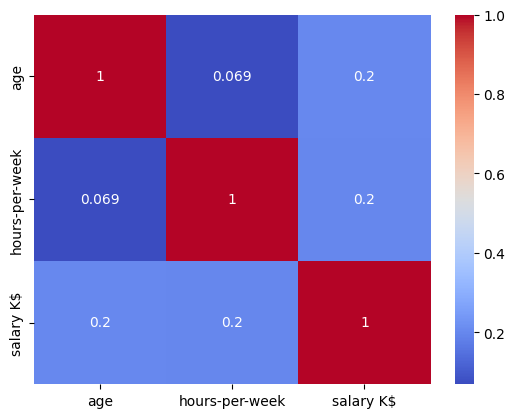

In [18]:
df_for_corr = df_cleaned[['age', 'hours-per-week', 'salary K$']]
correlation = df_for_corr.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
